# V-plot

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import pandas as pd


In [2]:
# Replace with your actual path to 'mapped.bed' if different
file_path = "mapped.bed"

heatmap_data = defaultdict(lambda: defaultdict(int))

with open(file_path, 'r') as f:
    for line in f:
        cols = line.strip().split('\t')
        if len(cols) < 11: continue

        c1 = (int(cols[2]) + int(cols[3])) // 2
        c2 = (int(cols[8]) + int(cols[9])) // 2
        x = c2 - c1
        y = int(cols[9]) - int(cols[8])

        heatmap_data[y][x] += 1


In [3]:
# Flatten data into DataFrame
x_vals = []
y_vals = []
z_vals = []

for y in sorted(heatmap_data.keys()):
    for x in sorted(heatmap_data[y].keys()):
        x_vals.append(x)
        y_vals.append(y)
        z_vals.append(heatmap_data[y][x])

df = pd.DataFrame({'X': x_vals, 'Y': y_vals, 'Z': z_vals})
pivot = df.pivot_table(index='Y', columns='X', values='Z', fill_value=0)


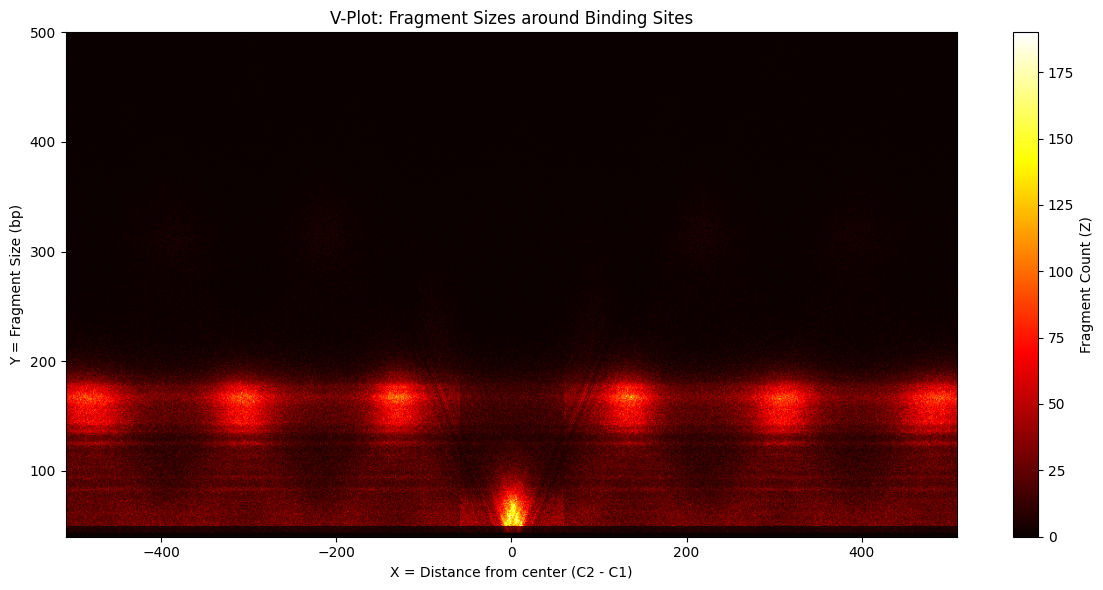

In [4]:
# Plot the heatmap
plt.figure(figsize=(12, 6))
plt.imshow(pivot.values, aspect='auto', cmap='hot', origin='lower',
           extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()])
plt.colorbar(label='Fragment Count (Z)')
plt.xlabel('X = Distance from center (C2 - C1)')
plt.ylabel('Y = Fragment Size (bp)')
plt.title('V-Plot: Fragment Sizes around Binding Sites')
plt.tight_layout()
plt.show()
